# Predictive Modeling using Machine Learning

In this notebook, we will build a machine learning model to predict whether a customer recommends a product (`Recommended IND`) based on their age, rating, and other categorical features.

## 1. Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

In [14]:
# Load the dataset
# We skip the first column as it's just an index
df = pd.read_csv('WomensClothingE-CommerceReviews.csv', engine='c', skipinitialspace=True)
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws ...,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy! ...,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt ...,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## 3. Data Preprocessing

In [15]:
# Define features (X) and target (y)
# We will use 'Age', 'Rating', 'Positive Feedback Count', and categorical features
target = 'Recommended IND'
features = ['Age', 'Rating', 'Positive Feedback Count', 'Department Name', 'Class Name']

# Drop rows where target is missing just in case
df = df.dropna(subset=[target])

X = df[features]
y = df[target]

# Define categorical and numerical features
numeric_features = ['Age', 'Rating', 'Positive Feedback Count']
categorical_features = ['Department Name', 'Class Name']

# Create preprocessor
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## 4. Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (18788, 5)
Testing data shape: (4698, 5)


## 5. Model Training & Evaluation

In [17]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Dictionary to store results
results = {}

for name, model in models.items():
    # Create pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])
    
    # Train model
    clf.fit(X_train, y_train)
    
    # Predict
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, 'predict_proba') else None
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    results[name] = {
        'model': clf,
        'accuracy': acc,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print()

--- Logistic Regression ---
Accuracy: 0.9323
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.89      0.83       851
           1       0.97      0.94      0.96      3847

    accuracy                           0.93      4698
   macro avg       0.87      0.92      0.89      4698
weighted avg       0.94      0.93      0.93      4698


--- Decision Tree ---
Accuracy: 0.9163
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77       851
           1       0.95      0.94      0.95      3847

    accuracy                           0.92      4698
   macro avg       0.86      0.87      0.86      4698
weighted avg       0.92      0.92      0.92      4698


--- Random Forest ---
Accuracy: 0.9229
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       851
           1       0.95      0.95      0.95

## 6. Visualizing Performance

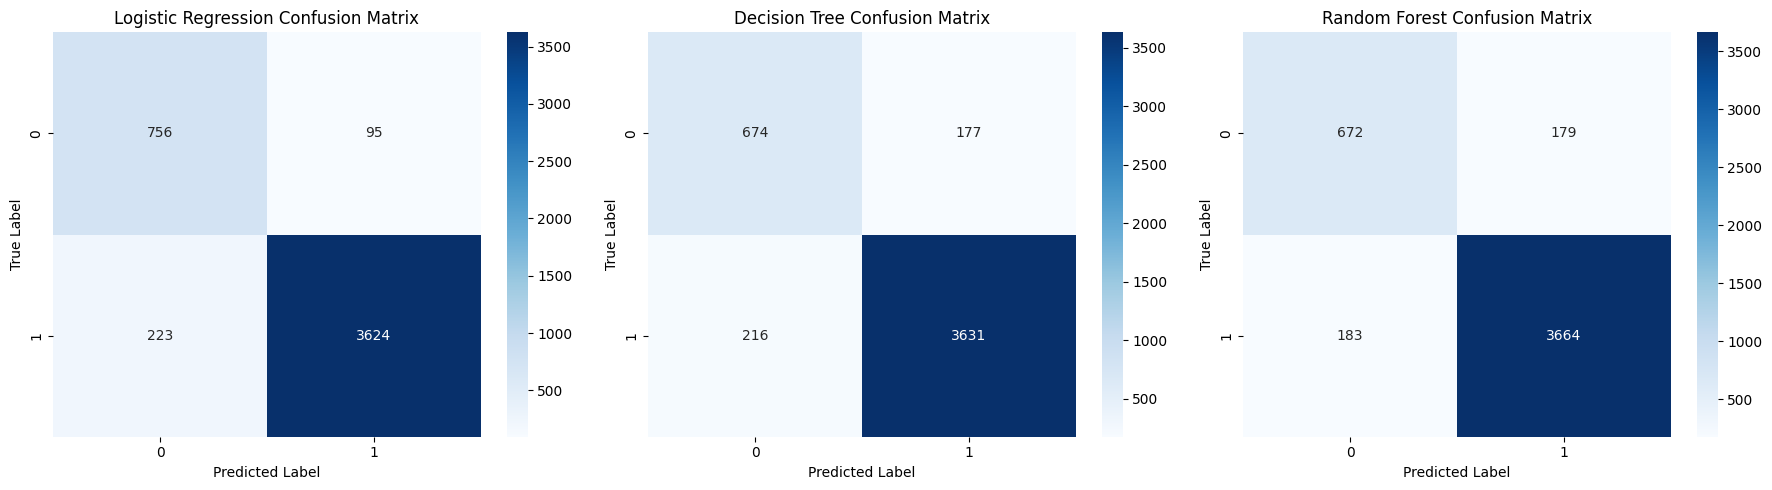

In [18]:
# 6.1 Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, result) in enumerate(results.items()):
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

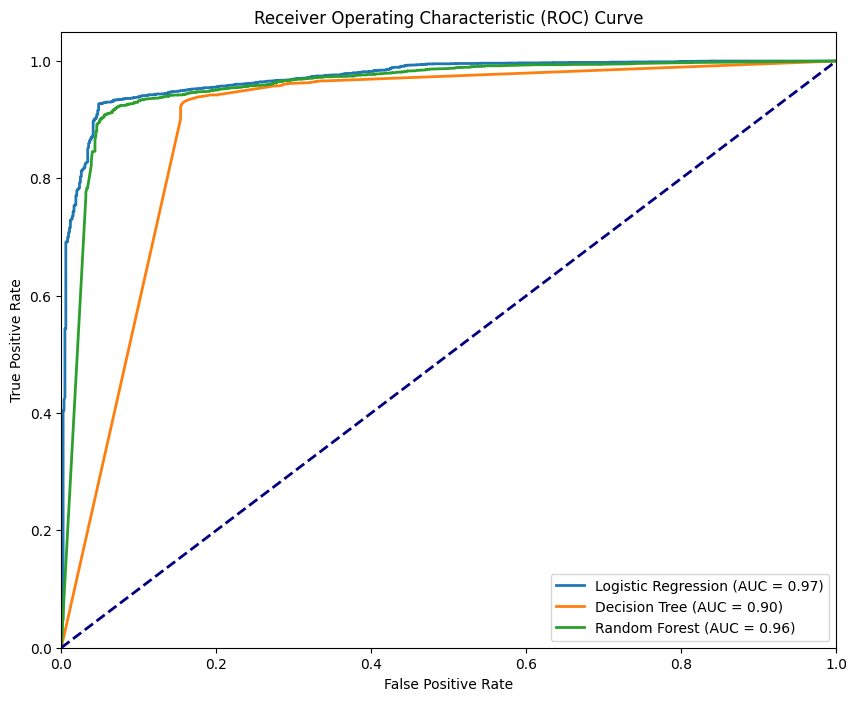

In [19]:
# 6.2 ROC Curves
plt.figure(figsize=(10, 8))

for name, result in results.items():
    if result['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()